In [1]:
import numpy as np
import xarray as xr
import datetime as dt
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from shapely.geometry import box

import matplotlib.pyplot as plt
from matplotlib import colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import requests 
import os


In [2]:
# Set up some example parameters for testing the function. You can modify these as needed.
cases = {}
cases['conus'] = {
    'plot_area': [360-128.0, 360-65.0, 20.0, 55.0], # CONUS (Hurricane Irene + Tropical Storm Lee)
    'time_range': ("2011-08-22 12:00:00", "2011-09-12 12:00:00"),
    'huc_codes': ['02', '03', '05', '06', '08']
}
cases['mid_atlantic'] = {
    'plot_area': [360-79.0, 360-73.0, 36.5, 43.0], # Mid-Atlantic (Flash floods)
    'time_range': ("2018-05-01 12:00:00", "2018-05-31 12:00:00"),
    'huc_codes': '02'
}
cases['pac_nw'] = {
    'plot_area': [360-126, 360-116.5, 41.5, 50.5],
    'time_range': ("2025-12-01 12:00:00", "2025-12-31 12:00:00"),
    'huc_codes': ['17110005','17110007'] # Upper Skagit and Skagit subbasins.
}


In [3]:
## Select the case.

case = 'pac_nw'  # December 2025 flooding
# case = 'mid_atlantic'  # May 2018 flooding
# case = 'conus'   # Hurricane Irene + Tropical Storm Lee


## Read in Stage IV precipitation data. Make some plots. Subset by HUC basin.

Stage IV data have been converted from the original GRIB format to .zarr.

In [4]:
def get_precip_colormap():

    ## Colormaps
    CMAP={}
    CMAP['rainrate24h_global']={}
    CMAP['rainrate24h_global']['vmin'] = 0.0
    CMAP['rainrate24h_global']['vmax'] = 12.0
    CMAP['rainrate24h_global']['interval'] = 0.5

    ## Start with "jet" colorbar and modify it to make it more suitable for precipitation.
    cmap = plt.cm.jet
    N_keep = 12
    cmap2 = colors.LinearSegmentedColormap.from_list(name='custom', colors=cmap(range(cmap.N)), N=N_keep)
    color_list1 = cmap2(range(cmap2.N))
    ## Modify individual colors here.
    color_list11 = cmap2(range(cmap2.N))
    color_list11[0] = [1,1,1,1] # Make first color white.
    color_list11[1] = [0.7,0.7,0.7, 1] # Make next color gray.
    color_list11[2] = [0.0, 0.9, 1.0, 1.0]
    color_list11[3] = [0.0/255.0, 156.0/255.0, 255.0/255.0, 1.0]
    color_list11[4] = [0.0/255.0, 58.0/255.0, 255.0/255.0, 1.0]
    color_list11[5] = [0.0, 0.5, 0.0, 1.]
    color_list11[6] = [0.0, 0.8, 0.0, 1.]
    color_list11[9] = color_list1[10]  # Move top to colors of jet color map down.
    color_list11[10] = color_list1[11] # Move top to colors of jet color map down.
    color_list11[11] = [1,0,1,1] # Magenta on top.

    ## Brighten
    import colorsys
    scale_l = 1.5
    max_l = 0.7
    for n in range(9, len(color_list11)):  ## Don't touch first two colors.
        h, l, s = colorsys.rgb_to_hls(*color_list11[n][0:3])
        color_list11[n][0:3] = colorsys.hls_to_rgb(h, min(max_l, l * scale_l), s = s)

    ## Add color map to the dict.
    CMAP = colors.LinearSegmentedColormap.from_list(name='custom_precip', colors=color_list11, N=N_keep)

    return CMAP

In [5]:
def get_precip_vmax(values):
    """
    Get the maximum value for the precipitation color bar, based on the data values.
    """
    n_colors = get_precip_colormap().N
    # Try to use a multiple of the number of colors 
    # So the colorbar can be divided into nice intervals.
    max_value = np.nanpercentile(values, 99.9)
    vmax = np.ceil(max_value / n_colors) * n_colors
    return vmax


### Define function for reading and subsetting data by time range and spatial extent.

In [6]:
def get_s4_kopah_precip_data(time_range, spatial_extent=None, interval="daily", ref_years=(2011, 2025)):
    """
    Read in Stage IV data from Kopah S3-compatible storage.
    Usage: get_s4_kopah_precip_data(time_range, spatial_extent=None, interval="daily")

    Time range is mandatory to avoid downloading the entire dataset. Spatial extent is optional, but will subset the data if provided.

    The data are available from January 2002 to near present (currently April 2026). However, hourly data over the western US is only
    reliable starting.
   
    Inputs:
    - time_range: tuple of two datetime objects (start, end) to subset the data
    - spatial_extent: tuple of four floats (lon_min, lon_max, lat_min, lat_max) to subset the data (optional)
    - interval: "daily" or "hourly" (default: "daily")
    - ref_years: tuple of two integers (start_year, end_year) to specify the reference years for the ERM data (default: (2011, 2025))
      + (Note: the reference years are only for the ERM data, and do not affect the precipitation data.)
      + The available reference years are:
        * 2006-2020 or 2011-2025 for daily data.
        * 2011-2025 for hourly data.
      + The full 2002 - 2026 data are available for each reference period.

    Returns:
    - xarray Dataset containing the requested data
    """

    if ref_years not in [(2006, 2020), (2011, 2025)]:
        raise ValueError(f"Unsupported reference years: '{ref_years}'. Please choose (2006, 2020) or (2011, 2025).")

    if interval == "daily":
        url = f"https://s3.kopah.uw.edu/gaia/bkerns/public/precip_and_erm/precip_and_erm_daily.s4_ending_12z.ref_{ref_years[0]}_{ref_years[1]}.zarr"
    elif interval == "hourly":
        if ref_years != (2011, 2025):
            raise ValueError(f"Hourly data is only available for reference years (2011, 2025). You provided {ref_years}.")
        url = f"https://s3.kopah.uw.edu/gaia/bkerns/public/precip_and_erm/precip_and_erm_hourly.s4_hourly.ref_{ref_years[0]}_{ref_years[1]}.zarr"
    else:
        raise ValueError(f"Unsupported interval: '{interval}'. Please choose 'daily' or 'hourly'.")

    ds = xr.open_zarr(url, zarr_version=2, consolidated=True)
    ds = ds.sel(time=slice(time_range[0], time_range[1]))

    if spatial_extent is not None:
        # This is a little trickier since the data is not on a regulat lat/lon grid.
        in_box = (ds["lon"] >= spatial_extent[0]) & (ds["lon"] <= spatial_extent[1]) & (ds["lat"] >= spatial_extent[2]) & (ds["lat"] <= spatial_extent[3])
        jj, ii = np.where(in_box.values)
        i_min, i_max = ii.min(), ii.max()
        j_min, j_max = jj.min(), jj.max()

        print(f"i bounds: {i_min} to {i_max}")
        print(f"j bounds: {j_min} to {j_max}")

        ds = ds.isel(x=slice(i_min, i_max), y=slice(j_min, j_max))

    return ds

In [7]:
def get_huc_gdf(huc_codes_list):
    """
    Get a GeoDataFrame of HUC geometries from the USGS API.
    Parameters:
    - huc_codes_list: list of HUC codes (str) to retrieve geometries
      OR a single HUC code (str) to retrieve geometry for that HUC.
    Returns:
    - merged_gdf: GeoDataFrame containing the geometries of the specified HUCs
    """

    if isinstance(huc_codes_list, str):
        huc_codes_list = [huc_codes_list]

    for hh, huc_code in enumerate(huc_codes_list):
        huc_level_str = str(len(huc_code)).zfill(2)
        url = (
            "https://api.water.usgs.gov/fabric/pygeoapi/collections/"
            f"nhdplushr-huc{huc_level_str}/items/{huc_code}"
        )
        print(url)
        params = {
            "f": "json",
        }

        # 1. Make the API call
        r = requests.get(url, params=params)
        r.raise_for_status()

        # 2. Convert the response into a dict
        geojson_dict = r.json()

        # 3. Pass the single feature inside a list to from_features()
        gdf = gpd.GeoDataFrame.from_features([geojson_dict], crs="EPSG:4326")
        if hh == 0:
            merged_gdf = gdf.copy()
        else:
            merged_gdf = gpd.GeoDataFrame(pd.concat([merged_gdf, gdf], ignore_index=True), crs=gdf.crs)

    return merged_gdf


In [8]:

plot_area = cases[case]['plot_area']
time_range = cases[case]['time_range']

ds = get_s4_kopah_precip_data(time_range=time_range, spatial_extent=plot_area, interval='daily', ref_years=(2011, 2025))
print(ds)


da_precip_pac_nw = ds['daily_precip']
da_precip_pac_nw_sum = da_precip_pac_nw.sum(dim="time")
print(da_precip_pac_nw_sum)
print(np.nanmax(da_precip_pac_nw_sum.values))

da_erm_pac_nw = ds["daily_erm"]
da_erm_pac_nw_max = da_erm_pac_nw.max(dim="time")
print(da_erm_pac_nw_max)
print(np.nanmax(da_erm_pac_nw_max.values))

/tmp/ipykernel_3092687/2006158540.py:38: FutureWarning: zarr_version is deprecated, use zarr_format
  ds = xr.open_zarr(url, zarr_version=2, consolidated=True)


i bounds: 0 to 220
j bounds: 498 to 762
<xarray.Dataset> Size: 15MB
Dimensions:           (time: 31, y: 264, x: 220)
Coordinates:
  * time              (time) datetime64[ns] 248B 2025-12-01T12:00:00 ... 2025...
    lat               (y, x) float32 232kB 39.72 39.73 39.75 ... 52.08 52.09
    lon               (y, x) float32 232kB 235.1 235.1 235.2 ... 242.8 242.9
Dimensions without coordinates: y, x
Data variables:
    daily_erm         (time, y, x) float32 7MB ...
    daily_precip      (time, y, x) float32 7MB ...
    doy               (time) int32 124B ...
    max_daily_erm     (y, x) float32 232kB ...
    max_daily_precip  (y, x) float32 232kB ...
Attributes:
    description:  NCEP Stage IV, daily data. Represents the 24 h period endin...
    crs:          +proj=stere +lat_0=90 +lat_ts=60 +lon_0=-105 +a=6371200 +b=...
<xarray.DataArray 'daily_precip' (y: 264, x: 220)> Size: 232kB
array([[  0.      ,   0.      ,   0.      , ...,   9.1     ,  37.6     ,
         29.3     ],
       [  0

## Plot a map of precip accumulation and maximum ERM for a time period.

Total precipitation tells how much precip fell during the time period.

Max ERM indicates the maximum flood potential occurring during the time period.

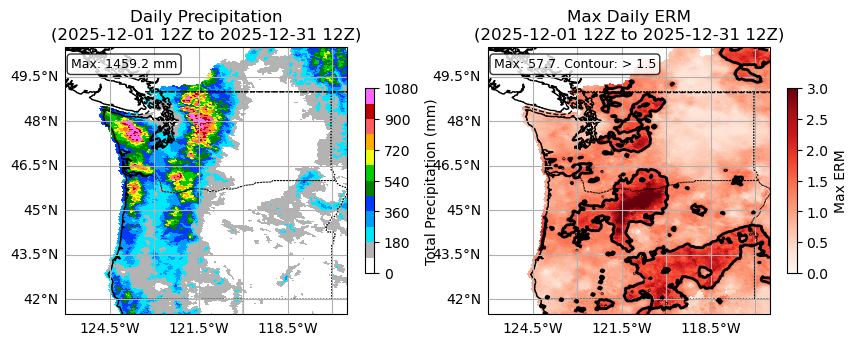

In [9]:
fig = plt.figure(figsize=(10, 4))
ax1 = plt.subplot(1,2,1,projection=ccrs.PlateCarree())
ax2 = plt.subplot(1,2,2,projection=ccrs.PlateCarree())
for ax in [ax1, ax2]:
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle="--")
    ax.add_feature(cfeature.STATES, linestyle=":", edgecolor="black", linewidth=0.8)
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False


vmax = get_precip_vmax(da_precip_pac_nw_sum.values)
cmap = get_precip_colormap()
h1 = ax1.pcolormesh(
    da_precip_pac_nw_sum['lon'].values,
    da_precip_pac_nw_sum['lat'].values,
    da_precip_pac_nw_sum.values,
    vmin=0, vmax=vmax,
    transform=ccrs.PlateCarree(),
    cmap=cmap
)
ax1.text(0.02, 0.96, f"Max: {np.nanmax(da_precip_pac_nw_sum.values):.1f} mm", transform=ax1.transAxes, fontsize=9, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
cbar = fig.colorbar(h1, ax=ax1, orientation="vertical", shrink=0.6, label="Total Precipitation (mm)")
cbar.set_ticks(np.arange(0, vmax+0.1, 2*vmax/cmap.N))
ax1.set_title("Daily Precipitation (2025-12-01 to 2025-12-10)")
ax1.set_extent(plot_area, crs=ccrs.PlateCarree())

h2 = ax2.pcolormesh(
    da_erm_pac_nw_max['lon'].values,
    da_erm_pac_nw_max['lat'].values,
    da_erm_pac_nw_max.values,
    transform=ccrs.PlateCarree(),
    cmap="Reds",
    vmin=0, vmax=3
)

erm_threshold_contour = 1.5

h22 = ax2.contour(
    da_erm_pac_nw_max['lon'].values,
    da_erm_pac_nw_max['lat'].values,
    da_erm_pac_nw_max.values,
    levels=[erm_threshold_contour,],
    colors='k',
    linewidths=2,
    transform=ccrs.PlateCarree()
)

ax2.text(0.02, 0.96, f"Max: {np.nanmax(da_erm_pac_nw_max.values):.1f}. Contour: > {erm_threshold_contour}", transform=ax2.transAxes, fontsize=9, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
cbar = fig.colorbar(h2, ax=ax2, orientation="vertical", shrink=0.6, label="Max ERM")

date_str_fmt = "%Y-%m-%d %HZ"
date_str1 = dt.datetime.strptime(time_range[0], "%Y-%m-%d %H:%M:%S").strftime(date_str_fmt)
date_str2 = dt.datetime.strptime(time_range[1], "%Y-%m-%d %H:%M:%S").strftime(date_str_fmt)

ax1.set_title(f"Daily Precipitation\n({date_str1} to {date_str2})")
ax1.set_extent(plot_area, crs=ccrs.PlateCarree())

ax2.set_title(f"Max Daily ERM\n({date_str1} to {date_str2})")
ax2.set_extent(plot_area, crs=ccrs.PlateCarree())


plt.show()

## Now focus on one or more HUC regions or river basins (e.g, Skagit River sub-basins)

### First, plot the total precip for just the grid points within the specific subbasin(s).

#### Quick test for the reading in HUC boundaries function.

https://api.water.usgs.gov/fabric/pygeoapi/collections/nhdplushr-huc08/items/17110005
https://api.water.usgs.gov/fabric/pygeoapi/collections/nhdplushr-huc08/items/17110007
                                            geometry   fid        08
0  MULTIPOLYGON (((-121.27551 49.16895, -121.2754...  2037  17110005
1  MULTIPOLYGON (((-121.70657 48.43501, -121.7066...  2039  17110007


<Axes: >

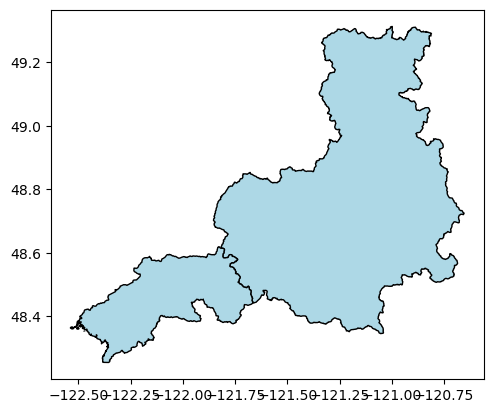

In [10]:
huc_codes = cases[case]['huc_codes']

merged_huc_gdf = get_huc_gdf(huc_codes)
print(merged_huc_gdf)

merged_huc_gdf.plot(facecolor='lightblue', edgecolor='black')


Reading HUC geometries from ../data/GIS/17110005_17110007.json...
Here is the merged HUC GeoDataFrame:
    fid        08                                           geometry
0  2037  17110005  MULTIPOLYGON (((-121.27551 49.16895, -121.2754...
1  2039  17110007  MULTIPOLYGON (((-121.70657 48.43501, -121.7066...
MULTIPOLYGON (((-121.27551197012718 49.16895380726573, -121.27546505367101 49.16902851352599, -121.27537835687717 49.169143566370906, -121.27523229302554 49.16930255789603, -121.27513253785278 49.169420005465376, -121.27502089536084 49.169577405507894, -121.2749513970595 49.16971763329958, -121.2748479929461 49.17003405549503, -121.27477907903695 49.170193062412345, -121.27456049362807 49.17060615323961, -121.27449632879868 49.170759567658806, -121.27444877864986 49.170919378295956, -121.27437689088458 49.17108837380217, -121.27427413627971 49.17126775149572, -121.27421890914286 49.171339260002874, -121.27410131710847 49.17151663700476, -121.27400331156593 49.1716904220726, -121.27

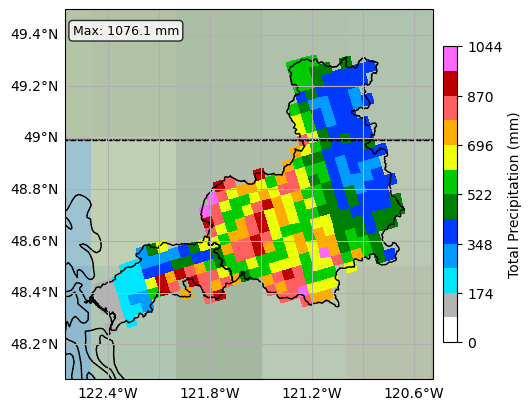

In [11]:
if isinstance(huc_codes, list):
    huc8_list_str = "_".join(huc_codes)
else:
    huc8_list_str = huc_codes
aoi_path = f'../data/GIS/{huc8_list_str}.json'

if not os.path.exists(aoi_path):
    print(f"Creating HUC geometries and saving to {aoi_path}...")
    merged_huc_gdf = get_huc_gdf(huc_codes)
    os.makedirs(os.path.dirname(aoi_path), exist_ok=True)
    merged_huc_gdf.to_file(aoi_path, driver="GeoJSON")
else:
    print(f"Reading HUC geometries from {aoi_path}...")
    merged_huc_gdf = gpd.read_file(aoi_path)

print("Here is the merged HUC GeoDataFrame:")
print(merged_huc_gdf)

# Mask the data using the HUC geometry
lat_vals = da_precip_pac_nw_sum['lat'].values.flatten()
lon_vals = da_precip_pac_nw_sum['lon'].values.flatten() - 360.0   

for hh, huc_geom in enumerate(merged_huc_gdf.geometry):
    print(huc_geom)
    print(huc_geom.contains(Point(-122.0, 48.0)))  # Example point to test if it's within the geometry
    if hh == 0:
        mask1d = np.array([huc_geom.contains(Point(lon, lat)) for lat, lon in zip(lat_vals, lon_vals)]) #[:,0]
    else:
        mask1d = mask1d | np.array([huc_geom.contains(Point(lon, lat)) for lat, lon in zip(lat_vals, lon_vals)]) #[:,0]

mask2d = np.array(mask1d).reshape(da_precip_pac_nw_sum['lat'].shape)


da_precip_pac_nw_sum_masked = da_precip_pac_nw_sum.where(mask2d)
da_erm_pac_nw_max_masked = da_erm_pac_nw_max.where(mask2d)
print(da_precip_pac_nw_sum_masked)
print(da_erm_pac_nw_max_masked)

buffer=0.2
plot_area_zoomed = [
    np.nanmin(lon_vals[mask1d]) - buffer,
    np.nanmax(lon_vals[mask1d]) + buffer,
    np.nanmin(lat_vals[mask1d]) - buffer,
    np.nanmax(lat_vals[mask1d]) + buffer
]

fig = plt.figure()
ax1 = plt.subplot(1,1,1,projection=ccrs.PlateCarree())
for ax in [ax1,]:
    ax1.stock_img()
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle="--")
    ax.add_feature(cfeature.STATES, linestyle=":", edgecolor="black", linewidth=0.8)
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

ax1.set_extent(plot_area_zoomed, crs=ccrs.PlateCarree())

vmax = get_precip_vmax(da_precip_pac_nw_sum_masked.values)
H = ax1.pcolormesh(
    da_precip_pac_nw_sum['lon'].values,
    da_precip_pac_nw_sum['lat'].values,
    da_precip_pac_nw_sum_masked.values,
    vmin=0, vmax=vmax,
    transform=ccrs.PlateCarree(),
    cmap=get_precip_colormap()
)

ax1.text(0.02, 0.96, f"Max: {np.nanmax(da_precip_pac_nw_sum_masked.values):.1f} mm", transform=ax1.transAxes, fontsize=9, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

cbar = fig.colorbar(H, ax=ax1, orientation="vertical", pad=0.02, shrink=0.8)
cbar.set_label("Total Precipitation (mm)")
cbar.set_ticks(np.arange(0, vmax + 1, 2*vmax/get_precip_colormap().N))

H = merged_huc_gdf.plot(
    ax=ax1,
    facecolor="none",
    edgecolor="black",
    linewidth=1,
    transform=ccrs.PlateCarree()
)
plt.show()




Try ERM plus Precip panels

Reading HUC geometries from ../data/GIS/17110005_17110007.json...
Here is the merged HUC GeoDataFrame:
    fid        08                                           geometry
0  2037  17110005  MULTIPOLYGON (((-121.27551 49.16895, -121.2754...
1  2039  17110007  MULTIPOLYGON (((-121.70657 48.43501, -121.7066...
MULTIPOLYGON (((-121.27551197012718 49.16895380726573, -121.27546505367101 49.16902851352599, -121.27537835687717 49.169143566370906, -121.27523229302554 49.16930255789603, -121.27513253785278 49.169420005465376, -121.27502089536084 49.169577405507894, -121.2749513970595 49.16971763329958, -121.2748479929461 49.17003405549503, -121.27477907903695 49.170193062412345, -121.27456049362807 49.17060615323961, -121.27449632879868 49.170759567658806, -121.27444877864986 49.170919378295956, -121.27437689088458 49.17108837380217, -121.27427413627971 49.17126775149572, -121.27421890914286 49.171339260002874, -121.27410131710847 49.17151663700476, -121.27400331156593 49.1716904220726, -121.27

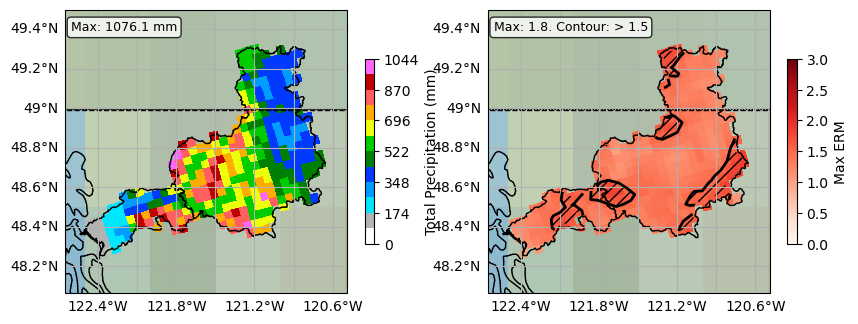

In [12]:
# Saved merged_huc_gdf to file for later use
# huc8_list = ['02040202', '02040203'] # Upper Skagit and Skagit subbasins.

if isinstance(huc_codes, list):
    huc8_list_str = "_".join(huc_codes)
else:
    huc8_list_str = huc_codes
aoi_path = f'../data/GIS/{huc8_list_str}.json'

if not os.path.exists(aoi_path):
    print(f"Creating HUC geometries and saving to {aoi_path}...")
    merged_huc_gdf = get_huc_gdf(huc_codes)
    merged_huc_gdf.to_file(aoi_path, driver="GeoJSON")
else:
    print(f"Reading HUC geometries from {aoi_path}...")
    merged_huc_gdf = gpd.read_file(aoi_path)

print("Here is the merged HUC GeoDataFrame:")
print(merged_huc_gdf)

# Mask the data using the HUC geometry
lat_vals = da_precip_pac_nw_sum['lat'].values.flatten()
lon_vals = da_precip_pac_nw_sum['lon'].values.flatten() - 360.0   

for hh, huc_geom in enumerate(merged_huc_gdf.geometry):
    print(huc_geom)
    print(huc_geom.contains(Point(-122.0, 48.0)))  # Example point to test if it's within the geometry
    if hh == 0:
        mask1d = np.array([huc_geom.contains(Point(lon, lat)) for lat, lon in zip(lat_vals, lon_vals)]) #[:,0]
    else:
        mask1d = mask1d | np.array([huc_geom.contains(Point(lon, lat)) for lat, lon in zip(lat_vals, lon_vals)]) #[:,0]

mask2d = np.array(mask1d).reshape(da_precip_pac_nw_sum['lat'].shape)


da_precip_pac_nw_sum_masked = da_precip_pac_nw_sum.where(mask2d)
da_erm_pac_nw_max_masked = da_erm_pac_nw_max.where(mask2d)
print(da_precip_pac_nw_sum_masked)
print(da_erm_pac_nw_max_masked)

buffer=0.2
plot_area_zoomed = [
    np.nanmin(lon_vals[mask1d]) - buffer,
    np.nanmax(lon_vals[mask1d]) + buffer,
    np.nanmin(lat_vals[mask1d]) - buffer,
    np.nanmax(lat_vals[mask1d]) + buffer
]

fig = plt.figure(figsize=(10, 4))
ax1 = plt.subplot(1,2,1,projection=ccrs.PlateCarree())
ax2 = plt.subplot(1,2,2,projection=ccrs.PlateCarree())
for ax in [ax1, ax2]:
    ax.stock_img()
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle="--")
    ax.add_feature(cfeature.STATES, linestyle=":", edgecolor="black", linewidth=0.8)
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False
    ax.set_extent(plot_area_zoomed, crs=ccrs.PlateCarree())

vmax = get_precip_vmax(da_precip_pac_nw_sum_masked.values)
H = ax1.pcolormesh(
    da_precip_pac_nw_sum['lon'].values,
    da_precip_pac_nw_sum['lat'].values,
    da_precip_pac_nw_sum_masked.values,
    vmin=0, vmax=vmax,
    transform=ccrs.PlateCarree(),
    cmap=get_precip_colormap()
)

cbar = fig.colorbar(H, ax=ax1, orientation="vertical", shrink=0.6, label="Total Precipitation (mm)")
cbar.set_label("Total Precipitation (mm)")
cbar.set_ticks(np.arange(0, vmax + 1, 2*vmax/get_precip_colormap().N))

h2 = ax2.pcolormesh(
    da_erm_pac_nw_max['lon'].values,
    da_erm_pac_nw_max['lat'].values,
    da_erm_pac_nw_max_masked.values,
    transform=ccrs.PlateCarree(),
    cmap="Reds",
    vmin=0, vmax=3
)
ax1.text(0.02, 0.96, f"Max: {np.nanmax(da_precip_pac_nw_sum_masked.values):.1f} mm", transform=ax1.transAxes, fontsize=9, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

erm_threshold_contour = 1.5

h22 = ax2.contour(
    da_erm_pac_nw_max['lon'].values,
    da_erm_pac_nw_max['lat'].values,
    da_erm_pac_nw_max_masked.values,
    levels=[erm_threshold_contour,],
    colors='k',
    linewidths=2,
    transform=ccrs.PlateCarree()
)
h22 = ax2.contourf(
    da_erm_pac_nw_max['lon'].values,
    da_erm_pac_nw_max['lat'].values,
    da_erm_pac_nw_max_masked.values,
    levels=[erm_threshold_contour,999.0],
    colors='none',
    hatches=['///'],
    transform=ccrs.PlateCarree()
)


ax2.text(0.02, 0.96, f"Max: {np.nanmax(da_erm_pac_nw_max_masked.values):.1f}. Contour: > {erm_threshold_contour}", transform=ax2.transAxes, fontsize=9, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
cbar = fig.colorbar(h2, ax=ax2, orientation="vertical", shrink=0.6, label="Max ERM")

for ax in [ax1, ax2]:
    H = merged_huc_gdf.plot(
            ax=ax,
            facecolor="none",
            edgecolor="black",
            linewidth=1,
            transform=ccrs.PlateCarree()
    )
plt.show()




### Next, get the daily and hourly time series of rain rates averaged over the subbasin(s).

#### For daily time series, I already extracted the data above.

Text(0, 0.5, 'Precipitation (mm/day)')

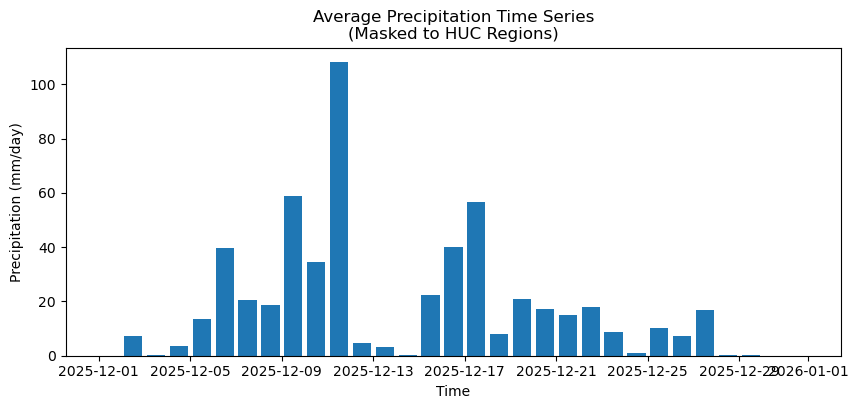

In [13]:
mask3d = np.expand_dims(mask2d, axis=0).repeat(da_precip_pac_nw.shape[0], axis=0)
da_precip_pac_nw_masked = da_precip_pac_nw.where(mask3d)

precip_masked_time_series = np.nanmean(da_precip_pac_nw_masked.values, axis=(1, 2))

fig = plt.figure(figsize=(10, 4))
ax1 = plt.subplot(1,1,1)
ax1.bar(da_precip_pac_nw['time'].values, precip_masked_time_series)
ax1.set_title("Average Precipitation Time Series\n(Masked to HUC Regions)")
ax1.set_xlabel("Time")
ax1.set_ylabel("Precipitation (mm/day)")

Do another one with including max ERM.

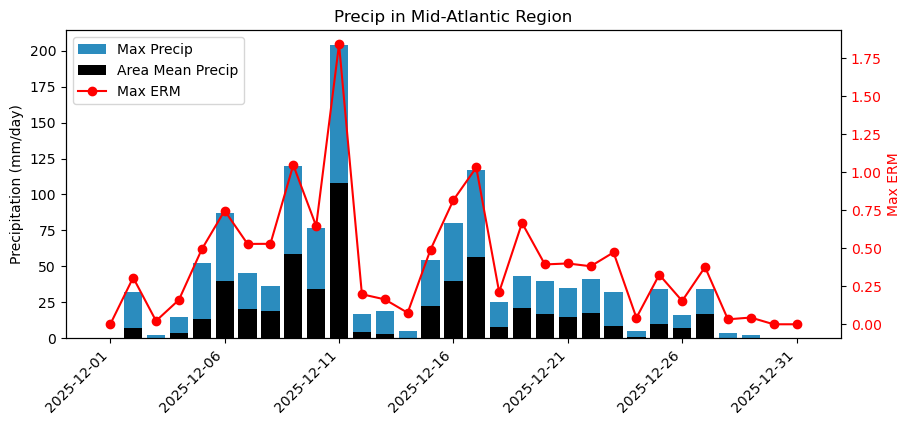

In [14]:
mask3d = np.expand_dims(mask2d, axis=0).repeat(da_precip_pac_nw.shape[0], axis=0)
da_precip_pac_nw_masked = da_precip_pac_nw.where(mask3d)
da_erm_pac_nw_max_masked = da_erm_pac_nw.where(mask3d)

col_max = '#2b8cbe'
col_mean = 'k'

precip_masked_time_series = np.nanmean(da_precip_pac_nw_masked.values, axis=(1, 2))
precip_max_masked_time_series = np.nanmax(da_precip_pac_nw_masked.values, axis=(1, 2))
max_erm_masked_time_series = np.nanmax(da_erm_pac_nw_max_masked.values, axis=(1, 2))

fig = plt.figure(figsize=(10, 4))
ax1 = plt.subplot(1,1,1)
h_max_precip = ax1.bar(da_precip_pac_nw['time'].values, precip_max_masked_time_series, color=col_max)
h_mean_precip = ax1.bar(da_precip_pac_nw['time'].values, precip_masked_time_series, color=col_mean)
ax1.set_title("Precip in Mid-Atlantic Region")
ax1.set_xticks(da_precip_pac_nw['time'].values[::5])  # Set x-ticks to every other time point
ax1.set_xticklabels([pd.to_datetime(t).strftime('%Y-%m-%d') for t in da_precip_pac_nw['time'].values[::5]], rotation=45, ha='right')
ax1.set_ylabel("Precipitation (mm/day)")

ax11 = ax1.twinx()
h_max_erm = ax11.plot(da_erm_pac_nw['time'].values, max_erm_masked_time_series, '-o', color='red', label='Max ERM')
ax11.set_ylabel("Max ERM", color='red')
ax11.tick_params(axis='y', labelcolor='red')

ax1.legend(handles=[h_max_precip, h_mean_precip, h_max_erm[0]], labels=['Max Precip', 'Area Mean Precip', 'Max ERM'], loc='upper left')

#### For hourly time series, I need to read in the hourly Stage IV data.

Because I have the area narrowed down to the subbasin(s), I can read in only this area, instead of 
the entire Pacific Northwest.

/tmp/ipykernel_3092687/2006158540.py:38: FutureWarning: zarr_version is deprecated, use zarr_format
  ds = xr.open_zarr(url, zarr_version=2, consolidated=True)


i bounds: 110 to 153
j bounds: 678 to 721
<xarray.DataArray 'hourly_precip' (time: 721, y: 43, x: 43)> Size: 5MB
[1333129 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 6kB 2025-12-01T12:00:00 ... 2025-12-31T12:...
    lat      (y, x) float32 7kB 47.71 47.72 47.73 47.74 ... 49.79 49.8 49.81
    lon      (y, x) float32 7kB 237.6 237.6 237.7 237.7 ... 239.2 239.2 239.3
Dimensions without coordinates: y, x
Reading HUC geometries from ../data/GIS/17110005_17110007.json...
Here is the merged HUC GeoDataFrame:
    fid        08                                           geometry
0  2037  17110005  MULTIPOLYGON (((-121.27551 49.16895, -121.2754...
1  2039  17110007  MULTIPOLYGON (((-121.70657 48.43501, -121.7066...


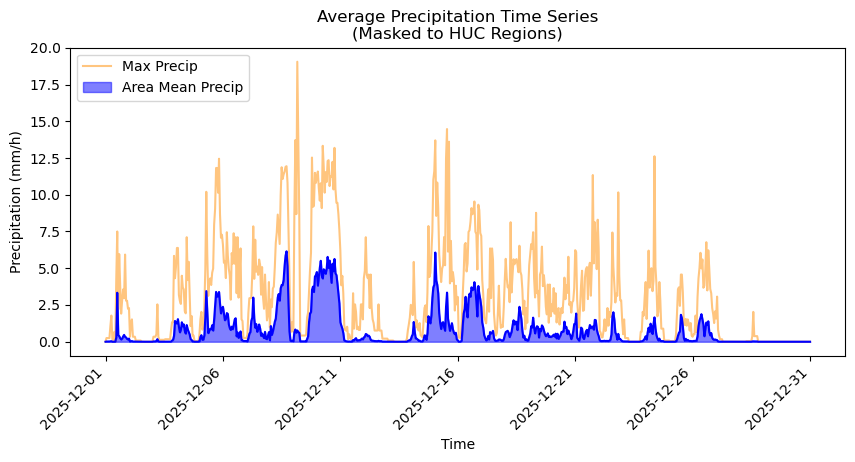

In [15]:
# time_range = ("2024-06-01 00:00:00", "2024-06-30 23:00:00")

spatial_extent = plot_area_zoomed.copy()
spatial_extent[0] = spatial_extent[0] + 360.0
spatial_extent[1] = spatial_extent[1] + 360.0

ds_hourly = get_s4_kopah_precip_data(time_range=time_range, spatial_extent=spatial_extent, interval='hourly')

da_precip_hourly = ds_hourly['hourly_precip']
print(da_precip_hourly)

# huc8_list = '02060003' #['02050306','02050101'] # Upper Skagit and Skagit subbasins.

aoi_path = f'../data/GIS/{huc8_list_str}.json'
if not os.path.exists(aoi_path):
    print(f"Creating HUC geometries and saving to {aoi_path}...")
    merged_huc_gdf = get_huc_gdf(huc8_list)
    merged_huc_gdf.to_file(aoi_path, driver="GeoJSON")
else:
    print(f"Reading HUC geometries from {aoi_path}...")
    merged_huc_gdf = gpd.read_file(aoi_path)

print("Here is the merged HUC GeoDataFrame:")
print(merged_huc_gdf)

lat_vals = da_precip_hourly['lat'].values.flatten()
lon_vals = da_precip_hourly['lon'].values.flatten() - 360.0   

for hh, huc_geom in enumerate(merged_huc_gdf.geometry):

    # Mask the data using the HUC geometry

    if hh == 0:
        mask1d = np.array([huc_geom.contains(Point(lon, lat)) for lat, lon in zip(lat_vals, lon_vals)]) #[:,0]
    else:
        mask1d = mask1d | np.array([huc_geom.contains(Point(lon, lat)) for lat, lon in zip(lat_vals, lon_vals)]) #[:,0]

mask2d = np.array(mask1d).reshape(da_precip_hourly['lat'].shape)

mask3d = np.expand_dims(mask2d, axis=0).repeat(da_precip_hourly.shape[0], axis=0)
da_precip_hourly_masked = da_precip_hourly.where(mask3d)

precip_hourly_masked_time_series = np.nanmean(da_precip_hourly_masked.values, axis=(1, 2))
precip_hourly_masked_time_series_max = np.nanmax(da_precip_hourly_masked.values, axis=(1, 2))

fig = plt.figure(figsize=(10, 4))
ax1 = plt.subplot(1,1,1)
h_max_precip, = ax1.plot(da_precip_hourly['time'].values, precip_hourly_masked_time_series_max, color="darkorange", alpha=0.5)

if np.nanmax(precip_hourly_masked_time_series) < 0.1 * np.nanmax(precip_hourly_masked_time_series_max):
    ax11 = ax1.twinx()
    h_mean_precip = ax11.fill_between(da_precip_hourly['time'].values, precip_hourly_masked_time_series, color="blue", alpha=0.5)
    ax11.plot(da_precip_hourly['time'].values, precip_hourly_masked_time_series, color="blue")
    ax11.set_ylabel("Area Mean Precipitation (mm/h)", color="blue")
    ax11.set_ylim(0, 0.1 * np.nanmax(precip_hourly_masked_time_series_max))
else:
    h_mean_precip = ax1.fill_between(da_precip_hourly['time'].values, precip_hourly_masked_time_series, color="blue", alpha=0.5)
    ax1.plot(da_precip_hourly['time'].values, precip_hourly_masked_time_series, color="blue")

ax1.set_title("Average Precipitation Time Series\n(Masked to HUC Regions)")
ax1.set_xlabel("Time")
ax1.set_ylabel("Precipitation (mm/h)")
ax1.set_xticks(da_precip_pac_nw['time'].values[::5])  # Set x-ticks to every other time point
ax1.set_xticklabels([pd.to_datetime(t).strftime('%Y-%m-%d') for t in da_precip_pac_nw['time'].values[::5]], rotation=45, ha='right')

ax1.legend(handles=[h_max_precip, h_mean_precip], labels=['Max Precip', 'Area Mean Precip'], loc='upper left')